In [ ]:
%pip install -q rdkit dscribe

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

from rdkit import Chem
from ase import Atoms
from dscribe.descriptors import ACSF

2026-05-10 14:35:04.624473: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-10 14:35:04.626891: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-10 14:35:04.653326: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-10 14:35:04.653357: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-10 14:35:04.654048: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [3]:
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

In [4]:
df = pd.read_csv('../gdb9.csv')

In [5]:
df.head()

,mol_id,A,B,C,mu,alpha,homo,lumo,gap,r2,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,gdb_1,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048,35.3641,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,gdb_2,293.60975,293.541110,191.393970,1.6256,9.46,-0.2570,0.0829,0.3399,26.1563,0.034358,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802
2,gdb_3,799.58812,437.903860,282.945450,1.8511,6.31,-0.2928,0.0687,0.3615,19.0002,0.021375,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171
3,gdb_4,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351,59.5248,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
4,gdb_5,0.00000,44.593883,44.593883,2.8937,12.99,-0.3604,0.0191,0.3796,48.7476,0.016601,-93.411888,-93.409370,-93.408425,-93.431246,6.278,-301.820534,-302.906752,-304.091489,-288.720028


In [6]:
target_column = "homo"

In [7]:
df.shape

(133885, 20)

In [8]:
suppl = Chem.SDMolSupplier("../gdb9.sdf", removeHs=False)
print(len(suppl))

133885


In [9]:
def extract_geometry(mol):
  conf = mol.GetConformer()

  atomic_numbers = []
  positions = []

  for atom in mol.GetAtoms():
    atomic_numbers.append(atom.GetAtomicNum())
    pos = conf.GetAtomPosition(atom.GetIdx())
    positions.append([pos.x, pos.y, pos.z])

  return np.array(atomic_numbers), np.array(positions)

In [10]:
Z, R = extract_geometry(suppl[0])
print(Z.shape, R.shape)

(5,) (5, 3)


In [11]:
def rdkit_to_ase(mol):
  Z, R = extract_geometry(mol)
  symbols = [Chem.PeriodicTable.GetElementSymbol(
      Chem.GetPeriodicTable(), int(z)) for z in Z]

  return Atoms(symbols=symbols, positions=R)

In [ ]:
species = ["H", "C", "N", "O", "F"]

acsf = ACSF(
    species=species,
    r_cut=5.0,
    g2_params=[
        [0.5, 0.0], [1.0, 0.0], [2.0, 0.0],
        [1.0, 1.0], [1.0, 2.0], [2.0, 1.0],
    ],
    g4_params=[[1.0, 1.0, 1.0], [1.0, 2.0, 1.0], [2.0, 1.0, 1.0]],
)

In [13]:
atoms = rdkit_to_ase(suppl[0])
features = acsf.create(atoms)
print(features.shape)

(5, 80)


In [14]:
max_atoms = 0

for mol in suppl:
  if mol is None:
    continue
  max_atoms = max(max_atoms, mol.GetNumAtoms())
print("Max atoms: ", max_atoms)

Max atoms:  29


In [ ]:
X_data = []
mask_data = []
y_data = []

for i, mol in enumerate(suppl):
  if mol is None:
    continue

  atoms = rdkit_to_ase(mol)
  features = acsf.create(atoms)
  n = features.shape[0]

  padded = np.zeros((max_atoms, features.shape[1]))
  padded[:n, :] = features

  m = np.zeros(max_atoms, dtype=np.float32)
  m[:n] = 1.0

  X_data.append(padded)
  mask_data.append(m)
  y_data.append(df.iloc[i][target_column])

X_data = np.asarray(X_data, dtype=np.float32)
atom_mask = np.asarray(mask_data, dtype=np.float32)
y_data = np.asarray(y_data, dtype=np.float32)

print(X_data.shape, atom_mask.shape, y_data.shape)

(131929, 29, 80) (131929, 29) (131929,)


In [ ]:
def atomic_network(n_features):
  reg = tf.keras.regularizers.l2(1e-6)
  inputs = tf.keras.layers.Input(shape=(n_features,))
  x = tf.keras.layers.Dense(160, activation="relu", kernel_regularizer=reg)(inputs)
  x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
  x = tf.keras.layers.Dense(96, activation="relu", kernel_regularizer=reg)(x)
  outputs = tf.keras.layers.Dense(1)(x)
  return tf.keras.Model(inputs, outputs)

In [ ]:
n_features = X_data.shape[2]
atomic_model = atomic_network(n_features)
feat_in = tf.keras.layers.Input(shape=(max_atoms, n_features), name="features")
mask_in = tf.keras.layers.Input(shape=(max_atoms,), name="mask")
atomic_energies = tf.keras.layers.TimeDistributed(atomic_model)(feat_in)

def masked_atomic_sum(args):
  ae, mask = args
  return tf.reduce_sum(ae * tf.expand_dims(mask, -1), axis=1)

total_energy = tf.keras.layers.Lambda(masked_atomic_sum)([atomic_energies, mask_in])
model = tf.keras.Model(inputs=[feat_in, mask_in], outputs=total_energy)
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 features (InputLayer)       [(None, 29, 80)]             0         []                            
                                                                                                  
 time_distributed (TimeDist  (None, 29, 1)                46049     ['features[0][0]']            
 ributed)                                                                                         
                                                                                                  
 mask (InputLayer)           [(None, 29)]                 0         []                            
                                                                                                  
 lambda (Lambda)             (None, 1)                    0         ['time_distributed[0][0]

2026-05-10 14:36:31.130037: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=["mae"],
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, m_train, m_test, y_train, y_test = train_test_split(
    X_data, atom_mask, y_data, test_size=0.2, random_state=42
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_mae", patience=10, restore_best_weights=True, min_delta=1e-4
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-5
    ),
]
model.fit(
    [X_train, m_train],
    y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/80
1320/1320 [==============================] - 5s 3ms/step - loss: 0.0419 - mae: 0.0540 - val_loss: 0.0015 - val_mae: 0.0286 - lr: 0.0010
Epoch 2/80
1320/1320 [==============================] - 4s 3ms/step - loss: 0.0014 - mae: 0.0266 - val_loss: 0.0043 - val_mae: 0.0567 - lr: 0.0010
Epoch 3/80
1320/1320 [==============================] - 5s 3ms/step - loss: 0.0021 - mae: 0.0322 - val_loss: 9.1221e-04 - val_mae: 0.0202 - lr: 0.0010
Epoch 4/80
1320/1320 [==============================] - 4s 3ms/step - loss: 0.0014 - mae: 0.0255 - val_loss: 0.0011 - val_mae: 0.0246 - lr: 0.0010
Epoch 5/80
1320/1320 [==============================] - 4s 3ms/step - loss: 8.7545e-04 - mae: 0.0201 - val_loss: 0.0014 - val_mae: 0.0310 - lr: 0.0010
Epoch 6/80
1320/1320 [==============================] - 4s 3ms/step - loss: 7.1232e-04 - mae: 0.0177 - val_loss: 5.1783e-04 - val_mae: 0.0134 - lr: 0.0010
Epoch 7/80
1320/1320 [==============================] - 4s 3ms/step - loss: 5.9939e-04 - mae: 0.0158 -

In [ ]:
model.evaluate([X_test, m_test], y_test, verbose=1)

825/825 [==============================] - 1s 1ms/step - loss: 1.5204e-04 - mae: 0.0075


[0.00015203628572635353, 0.007501751184463501]

In [ ]:
y_pred = model.predict([X_test, m_test], verbose=1)

825/825 [==============================] - 1s 1ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_p = np.asarray(y_pred).reshape(-1)
print(f"Test MAE:  {mean_absolute_error(y_test, y_p):.6f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_p)):.6f}")
print(f"Test R²:   {r2_score(y_test, y_p):.6f}")

Test MAE:  0.007502
Test RMSE: 0.010248
Test R²:   0.791443


In [ ]:
print(
    "Test MAE (numpy):",
    float(np.mean(np.abs(y_test - np.asarray(y_pred).reshape(-1)))),
)

Test MAE (numpy): 0.007501750718802214


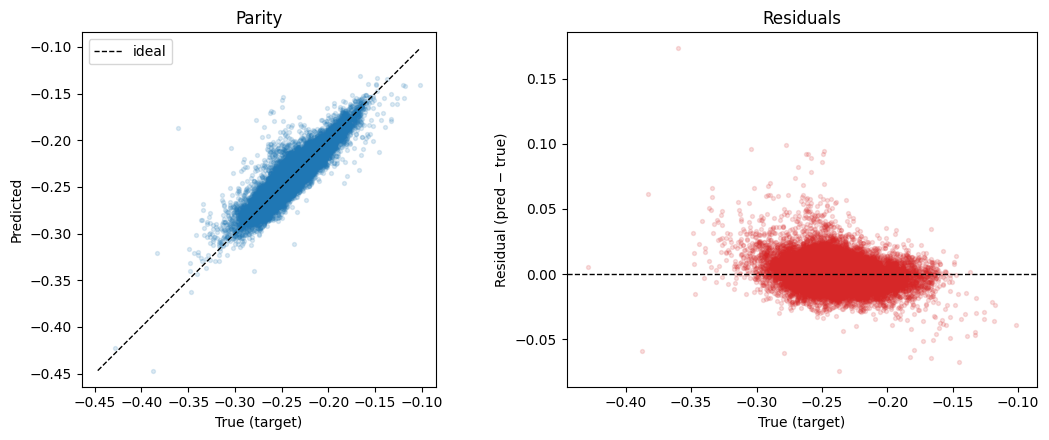

In [ ]:
import matplotlib.pyplot as plt

y_t = np.asarray(y_test).ravel()
y_p = np.asarray(y_pred).ravel()
lim = [min(y_t.min(), y_p.min()), max(y_t.max(), y_p.max())]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.scatter(y_t, y_p, alpha=0.15, s=8, c="C0", rasterized=True)
ax.plot(lim, lim, "k--", lw=1, label="ideal")
ax.set_xlabel("True (target)")
ax.set_ylabel("Predicted")
ax.set_title("Parity")
ax.legend()
ax.set_aspect("equal", adjustable="box")

ax2 = axes[1]
res = y_p - y_t
ax2.scatter(y_t, res, alpha=0.15, s=8, c="C3", rasterized=True)
ax2.axhline(0.0, color="k", linestyle="--", lw=1)
ax2.set_xlabel("True (target)")
ax2.set_ylabel("Residual (pred − true)")
ax2.set_title("Residuals")

plt.tight_layout()
plt.show()

In [ ]:
idx = 10
X_single = X_data[idx : idx + 1]
mask_single = atom_mask[idx : idx + 1]
prediction = model.predict([X_single, mask_single], verbose=0)
print("Predicted: ", prediction[0][0])
print("True: ", y_data[idx])

Predicted:  -0.24955004
True:  -0.254
